# Vásárlói adathalmaz – Kávézó

Ez az adathalmaz egy kávézó valós vásárlóit reprezentálja.  
Minden sor egy egyedi vásárlót jelöl, a következő oszlopokkal:

- **Életkor** – a vásárló életkora (év)  
- **Havi_látogatás** – a havi látogatások száma  
- **Átlagos_költés** – átlagos költés egy látogatás során (USD)  
- **Név** – a vásárló neve  


## 1. feladat

Olvassátok be az `klaszter_orai_feladat_2d.csv` fájlt egy DataFrame-be.  
Ellenőrizzétek az oszlopok adattípusát, és szükség esetén állítsátok be a megfelelő típusokat:  

- **Életkor** és **Havi_látogatás** legyen egész szám (`int`)  
- **Átlagos_költés** legyen lebegőpontos (`float`)  
- **Név** legyen szöveg (`string/object`)  

Ezután nézzétek meg az adatok első néhány sorát, és győződjetek meg róla, hogy minden helyes.

In [1]:
import pandas as pd

# CSV beolvasása
df = pd.read_csv('klaszter_orai_feladat_2d.csv')

# Adattípusok beállítása
df['Életkor'] = df['Életkor'].astype(int)
df['Havi_látogatás'] = df['Havi_látogatás'].astype(int)
df['Átlagos_költés'] = df['Átlagos_költés'].astype(float)
df['Név'] = df['Név'].astype(str)

# Ellenőrzés: adattípusok és első néhány sor
print(df.dtypes)
print(df.head())

Életkor             int64
Havi_látogatás      int64
Átlagos_költés    float64
Név                object
dtype: object
   Életkor  Havi_látogatás  Átlagos_költés           Név
0       25               3       13.238443     Feri Nagy
1       29               3        8.829315    Júlia Tóth
2       29               4        7.652628   Bence Szabó
3       26               2        7.671351    Hanna Nagy
4       25               0        1.375411  Gábor Kovács


## 2. feladat

Hozzatok létre egy új DataFrame-et, ami csak a **Havi_látogatás** és az **Átlagos_költés** oszlopokat tartalmazza.  
Mentés előtt ellenőrizzétek az új DataFrame-et, hogy csak a kívánt oszlopok legyenek benne.

In [2]:
# Új DataFrame létrehozása a két kiválasztott oszloppal
df_visits_purchase = df[['Havi_látogatás', 'Átlagos_költés']].copy()

# Ellenőrzés
print(df_visits_purchase.head())
print(df_visits_purchase.dtypes)

   Havi_látogatás  Átlagos_költés
0               3       13.238443
1               3        8.829315
2               4        7.652628
3               2        7.671351
4               0        1.375411
Havi_látogatás      int64
Átlagos_költés    float64
dtype: object


## 3. feladat

Határozzátok meg az optimális klaszterszámot a **könyökmódszer** segítségével a `df_visits_purchase` DataFrame-en.  

- A for ciklus 1-től 6-ig fusson, minden klaszterszámra számoljuk ki a KMeans **inertia_** értékét.  
- Rajzoljátok ki az eredményt **vonaldiagram** és **pontdiagram** segítségével.  
- A pontdiagram pontjai legyenek **zöld színűek**.

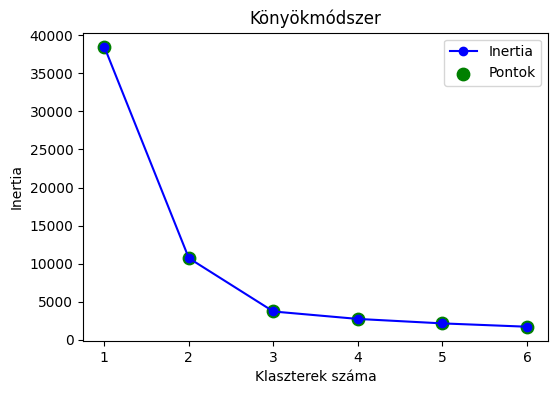

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Inertia értékek tárolása
err = []

# For ciklus 1-től 6 klaszterig
for i in range(1, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_visits_purchase)
    err.append([i, kmeans.inertia_])

# NumPy tömbbé alakítás
err = np.array(err)

# Vonaldiagram és pontdiagram
plt.figure(figsize=(6,4))
plt.plot(err[:,0], err[:,1], marker='o', color='blue', label='Inertia')  # vonaldiagram
plt.scatter(err[:,0], err[:,1], color='green', s=80, label='Pontok')      # pontdiagram zölddel
plt.xticks(range(1,7))
plt.xlabel('Klaszterek száma')
plt.ylabel('Inertia')
plt.title('Könyökmódszer')
plt.legend()
plt.show()

## 4. feladat

- Hozz létre egy változót `kmeans_2d` néven, amely a **KMeans modellt** tartalmazza az optimális klaszterszámmal (a 3. feladat alapján).  
- Tanítsd be a `df_visits_purchase` adatokon.  
- Vizualizáld az eredményt 2D scatter plot segítségével, ahol minden pont színe a hozzá tartozó klasztert jelzi.  
- A **klaszterközéppontok (centroidok) is legyenek feltűntetve**, például nagyobb, piros jelöléssel a scatteren.

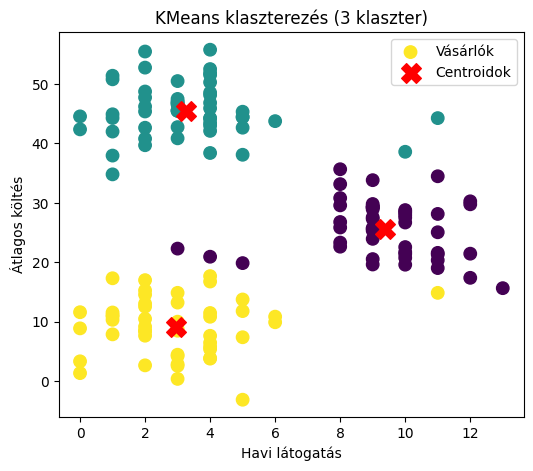

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Feltételezzük, hogy a 3. feladatból a “könyök” alapján az optimális klaszterszám 3
optimal_clusters = 3

# KMeans modell létrehozása és tanítása
kmeans_2d = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans_2d.fit(df_visits_purchase)

# Predikciók a klaszterekhez
labels = kmeans_2d.labels_

# Vizualizáció 2D scatter-rel
plt.figure(figsize=(6,5))
# Adatpontok
plt.scatter(df_visits_purchase['Havi_látogatás'],
            df_visits_purchase['Átlagos_költés'],
            c=labels, cmap='viridis', s=80, label='Vásárlók')

# Klaszterközéppontok
plt.scatter(kmeans_2d.cluster_centers_[:,0], 
            kmeans_2d.cluster_centers_[:,1],
            c='red', s=200, marker='X', label='Centroidok')

plt.xlabel('Havi látogatás')
plt.ylabel('Átlagos költés')
plt.title(f'KMeans klaszterezés ({optimal_clusters} klaszter)')
plt.legend()
plt.show()

## 5. feladat

- Hozz létre egy új KMeans klaszterezőt `kmeans_3d` néven, most a **három numerikus oszlop** (`Életkor`, `Havi_látogatás`, `Átlagos_költés`) alapján.  
- A klaszterszám legyen **3**.  
- Tanítsd be a modellt, majd ábrázold az eredményt **3D scatter plot** segítségével, ahol a pontok színe a klasztereket jelzi, és a **klaszterközéppontok is megjelennek**.

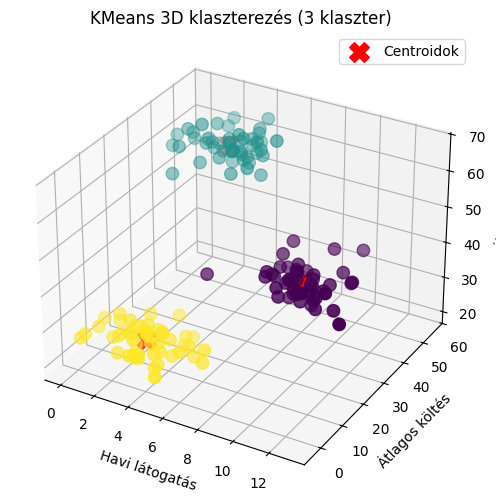

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# KMeans 3D klaszterezés
kmeans_3d = KMeans(n_clusters=3, random_state=42)
kmeans_3d.fit(df[['Életkor', 'Havi_látogatás', 'Átlagos_költés']])

# Predikciók
labels_3d = kmeans_3d.labels_

# 3D scatter plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Adatpontok
sc = ax.scatter(df['Havi_látogatás'], df['Átlagos_költés'], df['Életkor'],
                c=labels_3d, cmap='viridis', s=80)

# Klaszterközéppontok
ax.scatter(kmeans_3d.cluster_centers_[:,1],  # Havi_látogatás
           kmeans_3d.cluster_centers_[:,2],  # Átlagos_költés
           kmeans_3d.cluster_centers_[:,0],  # Életkor
           c='red', s=200, marker='X', label='Centroidok')

# Tengelyek
ax.set_xlabel('Havi látogatás')
ax.set_ylabel('Átlagos költés')
ax.set_zlabel('Életkor')
ax.set_title('KMeans 3D klaszterezés (3 klaszter)')

# Jelmagyarázat
ax.legend()
plt.show()